# Driving Kalix from Python

This notebook runs a Sacramento catchment model directly from Python using the [`kalix`](https://pypi.org/project/kalix/) package, then reads and plots the results as pandas DataFrames.

Install with:

```bash
pip install kalix
```

In [1]:
import kalix
import pandas as pd

print(f"kalix version: {kalix.__version__}")

kalix version: 0.2.5


## Run the model

`kalix.simulate()` runs an INI model in-process — no separate Kalix CLI binary required. The output format is inferred from the file extension; here we ask for CSV.

In [2]:
kalix.simulate("stringybark.ini", output_file="results.csv")

## Read the output as a DataFrame

Outputs land on disk in whatever format you asked for. Read CSV back with pandas, then everything else is standard data-science work.

In [3]:
sim = pd.read_csv("results.csv", parse_dates=[0], index_col=0)
sim.head()

,node.0001_sc_stringybark.dsflow,node.0001_sc_stringybark.ds_1,node.0001_sc_stringybark.flosf,node.0001_sc_stringybark.flobf,node.0001_sc_stringybark.floin,node.0002_ga_widebridge.dsflow
Time,,,,,,
1980-01-01,0.000000,0.000000,0.0,0.000000,0.0,0.000000
1980-01-02,0.000000,0.000000,0.0,0.000000,0.0,0.000000
1980-01-03,0.000000,0.000000,0.0,0.000000,0.0,0.000000
1980-01-04,0.000000,0.000000,0.0,0.000000,0.0,0.000000
1980-01-05,26.784732,26.784732,0.0,26.912094,0.0,26.784732


## Plot simulated vs observed

Load the observed streamflow at the gauge and overlay it against the simulated downstream flow from the model.

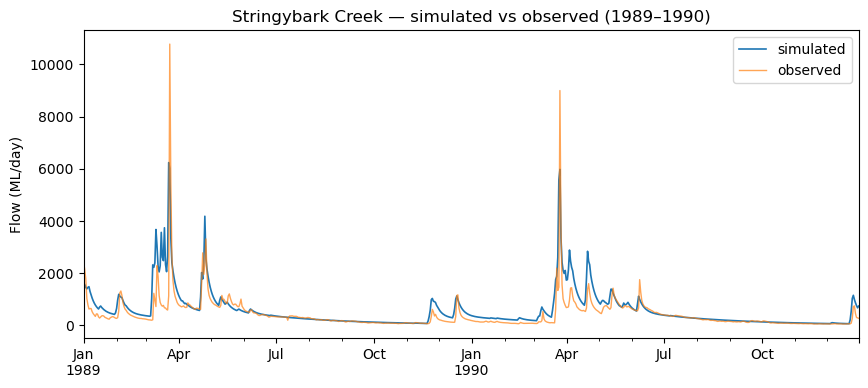

In [4]:
import matplotlib.pyplot as plt

obs = pd.read_csv("../../data/observed.csv", parse_dates=["Date"], index_col="Date")

fig, ax = plt.subplots(figsize=(10, 4))
window = slice("1989-01-01", "1990-12-31")
sim.loc[window, "node.0002_ga_widebridge.dsflow"].plot(ax=ax, label="simulated", linewidth=1.2)
obs.loc[window, "obs"].plot(ax=ax, label="observed", alpha=0.7, linewidth=1.0)
ax.set_ylabel("Flow (ML/day)")
ax.set_xlabel("")
ax.set_title("Stringybark Creek \u2014 simulated vs observed (1989\u20131990)")
ax.legend();

## Bonus — Pixie format

Kalix's native output format is **Pixie** — Gorilla-compressed timeseries written as a `.pxt` / `.pxb` pair. It's much smaller and faster to read than CSV for big runs.

Ask for Pixie by giving `.pxb` as the output extension, then read it back with `kalix.read_pixie()`. You get a DataFrame with a UTC `DatetimeIndex` named `"time"` and one column per output series — same shape as the CSV path.

In [5]:
kalix.simulate("stringybark.ini", output_file="results.pxb")
sim_pxb = kalix.read_pixie("results.pxb")
sim_pxb.head()

,node.0001_sc_stringybark.dsflow,node.0001_sc_stringybark.ds_1,node.0001_sc_stringybark.flosf,node.0001_sc_stringybark.flobf,node.0001_sc_stringybark.floin,node.0002_ga_widebridge.dsflow
time,,,,,,
1980-01-01 00:00:00+00:00,0.000000,0.000000,0.0,0.000000,0.0,0.000000
1980-01-02 00:00:00+00:00,0.000000,0.000000,0.0,0.000000,0.0,0.000000
1980-01-03 00:00:00+00:00,0.000000,0.000000,0.0,0.000000,0.0,0.000000
1980-01-04 00:00:00+00:00,0.000000,0.000000,0.0,0.000000,0.0,0.000000
1980-01-05 00:00:00+00:00,26.784733,26.784733,0.0,26.912094,0.0,26.784733


## What next

- Add `mass_balance="mbal.txt"` to `kalix.simulate(...)` to also write the mass-balance report.
- Loop over a scale factor on rainfall, stack the runs into one DataFrame, and compute statistics across scenarios.
- Use `kalix.write_pixie()` to round-trip your own DataFrames into Pixie.